In [1]:
# MNIST Dataset Load
import tensorflow as tf

mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 정규화
x_train, x_test = x_train / 255.0, x_test / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
# Model
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(1000, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1000)           │       785,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │        10,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 795,010 (3.03 MB)

 Trainable params: 795,010 (3.03 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
hist = model.fit(x_train,
                 y_train,
                 epochs=10,
                 batch_size=100,
                 validation_data=(x_test, y_test))

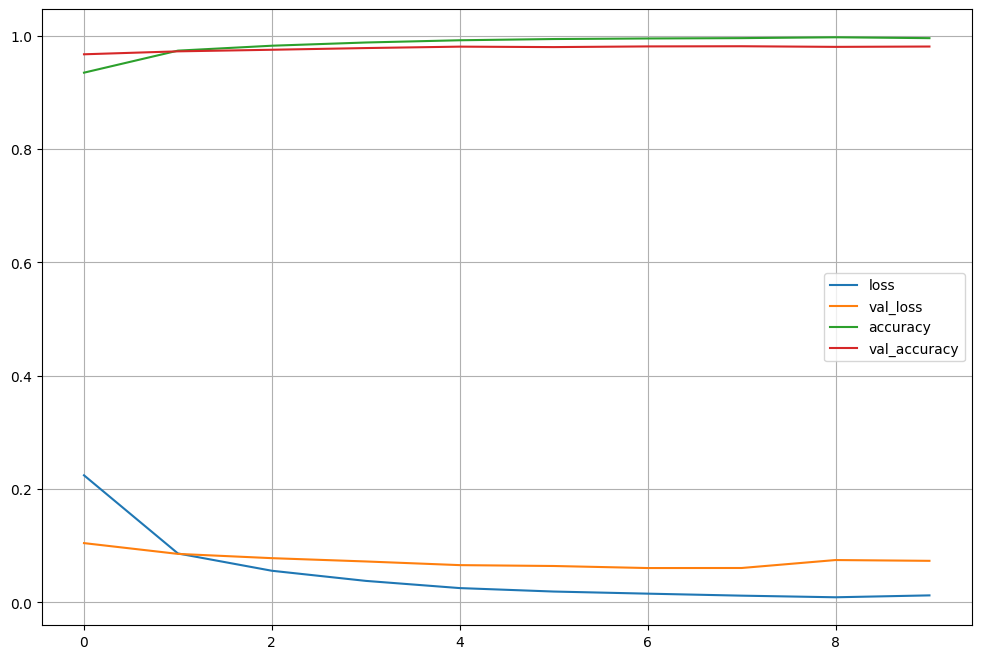

In [6]:
# Metrics 시각화
import matplotlib.pyplot as plt

plot_target = ['loss', 'val_loss', 'accuracy', 'val_accuracy']

plt.figure(figsize=(12, 8))

for metric in plot_target:
    plt.plot(hist.history[metric], label=metric)

plt.legend()
plt.grid()
plt.show()

In [7]:
# Evaluate
score = model.evaluate(x_test, y_test, verbose=0)

print(f'Test Loss: {score[0]}')
print(f'Test Accuracy: {score[1]}')

Test Loss: 0.07332565635442734
Test Accuracy: 0.9811999797821045


In [8]:
# 실제값과 예측값 비교
import numpy as np

predicted_result = model.predict(x_test)
predicted_labels = np.argmax(predicted_result, axis=1)

print(f'Predicted Labels: {predicted_labels[:10]}')
print(f'Real Labels: {y_test[:10]}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Predicted Labels: [7 2 1 0 4 1 4 9 5 9]
Real Labels: [7 2 1 0 4 1 4 9 5 9]


In [11]:
# 틀린 데이터 보기
wrong_result = []

for i in range(0, len(y_test)):
    if predicted_labels[i] != y_test[i]:
        wrong_result.append(i)
len(wrong_result)

188

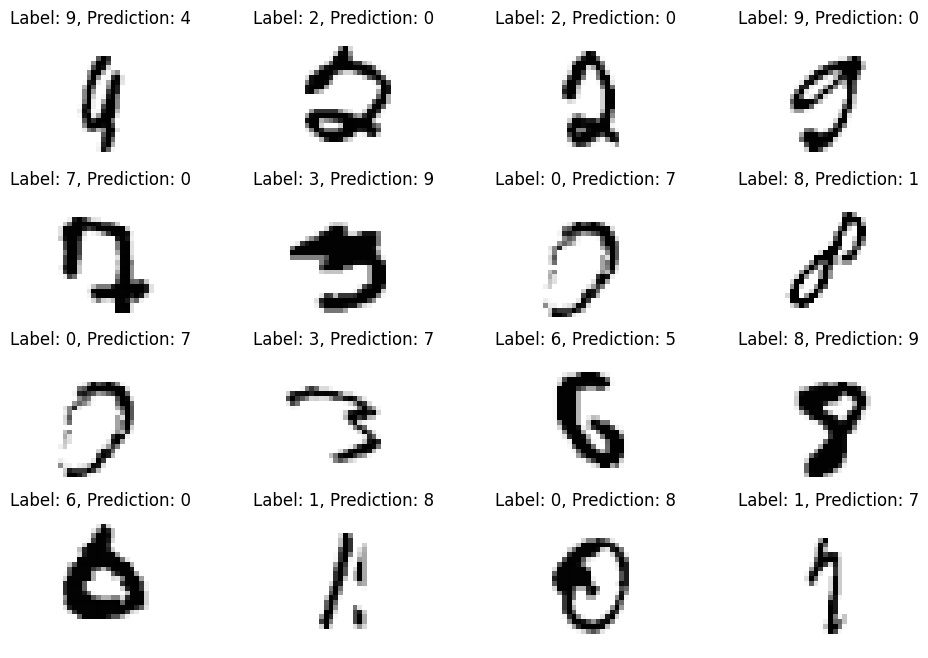

In [12]:
# 16개만 랜덤으로 추출하여 보기
# 틀린 데이터를 살펴보는 것도 매우 중요하다
import random

samples = random.choices(population=wrong_result, k=16)

plt.figure(figsize=(12, 8))

for idx, i in enumerate(samples):
    plt.subplot(4, 4, idx + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='Greys')
    plt.title(f'Label: {y_test[i]}, Prediction: {predicted_labels[i]}')
    plt.axis('off')

plt.show()

In [13]:
# Fashion MNIST Dataset Load
fashion_mnist = tf.keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# 정규화
x_train, x_test = x_train / 255.0, x_test / 255.0

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [14]:
# Model
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(1000, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1000)           │       785,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │        10,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 795,010 (3.03 MB)

 Trainable params: 795,010 (3.03 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
hist = model.fit(x_train,
                 y_train,
                 epochs=10,
                 batch_size=100,
                 validation_data=(x_test, y_test))

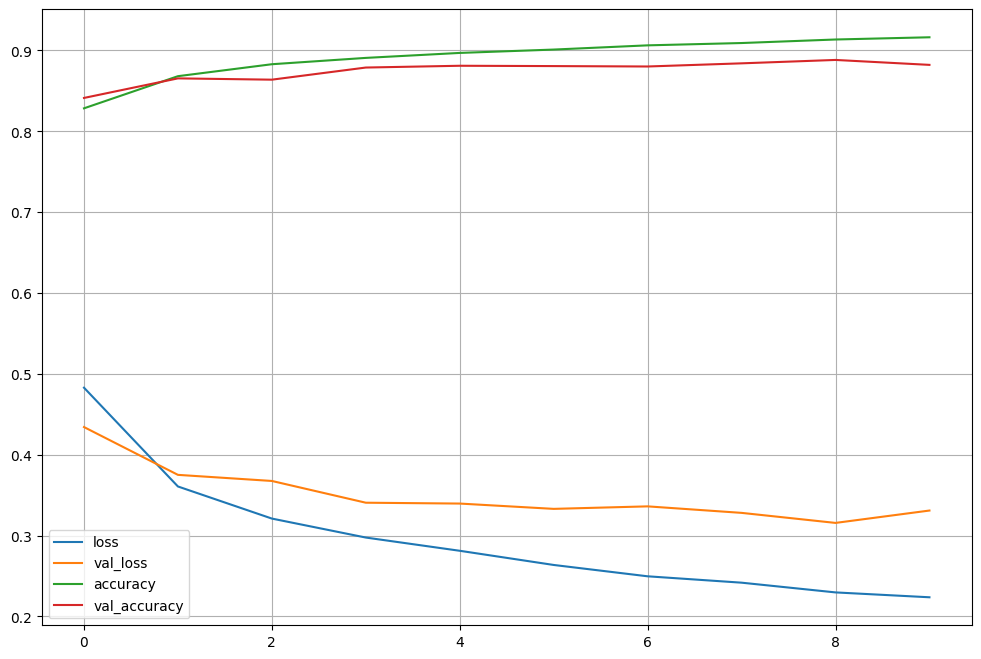

In [16]:
# Metrics 시각화
plot_target = ['loss', 'val_loss', 'accuracy', 'val_accuracy']

plt.figure(figsize=(12, 8))

for metric in plot_target:
    plt.plot(hist.history[metric], label=metric)

plt.legend()
plt.grid()
plt.show()

In [17]:
# Evaluate
score = model.evaluate(x_test, y_test, verbose=0)

print(f'Test Loss: {score[0]}')
print(f'Test Accuracy: {score[1]}')

Test Loss: 0.3309793174266815
Test Accuracy: 0.8822000026702881


In [18]:
# 실제값과 예측값 비교
predicted_result = model.predict(x_test)
predicted_labels = np.argmax(predicted_result, axis=1)

print(f'Predicted Labels: {predicted_labels[:10]}')
print(f'Real Labels: {y_test[:10]}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Predicted Labels: [9 2 1 1 6 1 4 6 5 7]
Real Labels: [9 2 1 1 6 1 4 6 5 7]


In [19]:
# 틀린 데이터 보기
wrong_result = []

for i in range(0, len(y_test)):
    if predicted_labels[i] != y_test[i]:
        wrong_result.append(i)
len(wrong_result)

1178

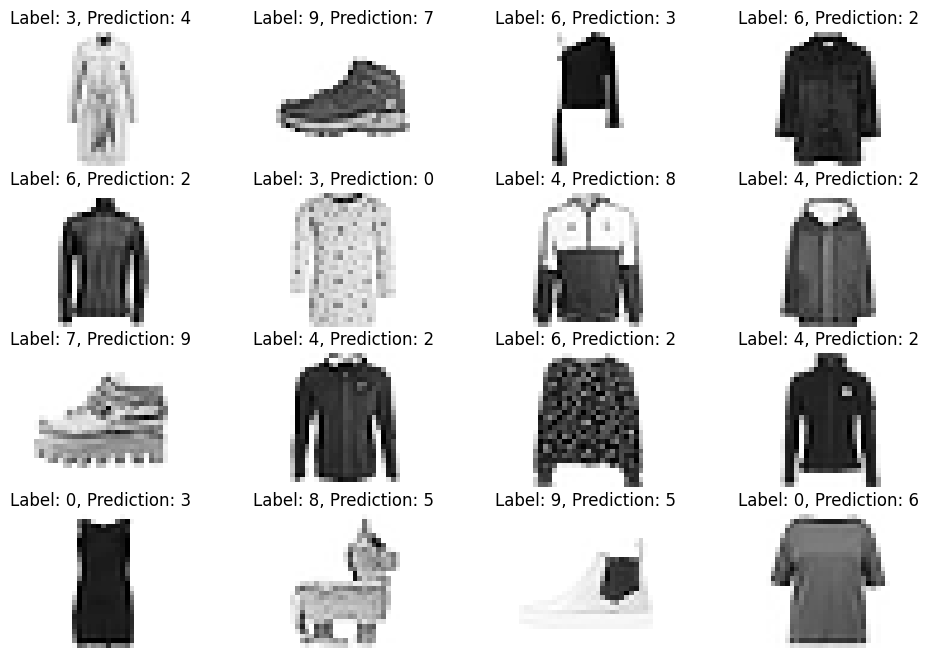

In [20]:
samples = random.choices(population=wrong_result, k=16)

plt.figure(figsize=(12, 8))

for idx, i in enumerate(samples):
    plt.subplot(4, 4, idx + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='Greys')
    plt.title(f'Label: {y_test[i]}, Prediction: {predicted_labels[i]}')
    plt.axis('off')

plt.show()